**Analisis Regresi dan Pencarian Akar untuk Menentukan Break Even Point pada Lima Gerai Donat**

Analisis dilakukan untuk mengetahui hubungan antara jumlah penjualan
dan pendapatan kotor pada lima gerai donat, kemudian menggunakan
hasil regresi untuk menentukan jumlah penjualan yang menghasilkan
Break Even Point (BEP) dengan metode pencarian akar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv('sintesis_data_donat_harian.csv')

df.head()

Saving sintesis_data_donat_harian.csv to sintesis_data_donat_harian.csv


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [3]:
print("Jumlah baris data :", len(df))
print("Jumlah kolom      :", len(df.columns))

print("\nNama kolom:")
print(df.columns.tolist())
df.info()
df.isnull().sum()

Jumlah baris data : 450
Jumlah kolom      : 8

Nama kolom:
['Tanggal', 'Gerai', 'Harga Jual (Rp)', 'Jumlah Terjual (Unit)', 'Pendapatan Kotor (Rp)', 'Biaya Variabel (Rp)', 'Fixed Cost Harian (Rp)', 'Balance (Rp)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB


,0
Tanggal,0
Gerai,0
Harga Jual (Rp),0
Jumlah Terjual (Unit),0
Pendapatan Kotor (Rp),0
Biaya Variabel (Rp),0
Fixed Cost Harian (Rp),0
Balance (Rp),0


In [4]:
df['Gerai'].value_counts().sort_index()

,count
Gerai,
Gerai A,90
Gerai B,90
Gerai C,90
Gerai D,90
Gerai E,90


Dataset terdiri dari 450 observasi

yang berasal dari lima gerai.
Masing-masing gerai memiliki 90 observasi harian.

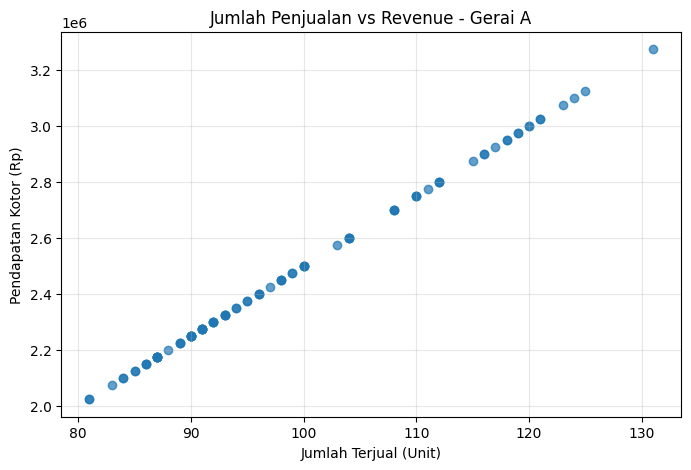

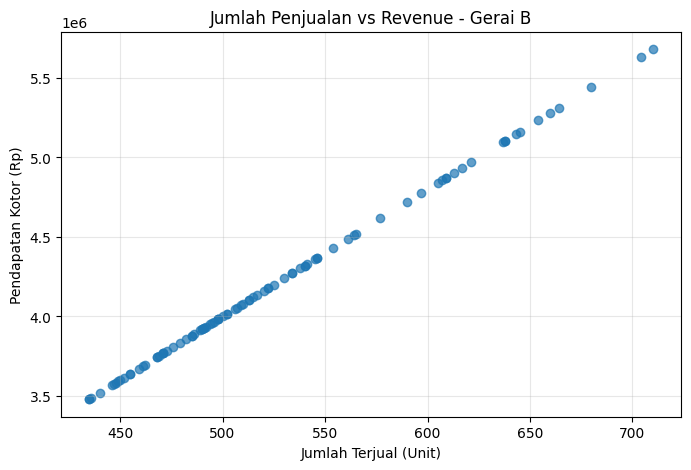

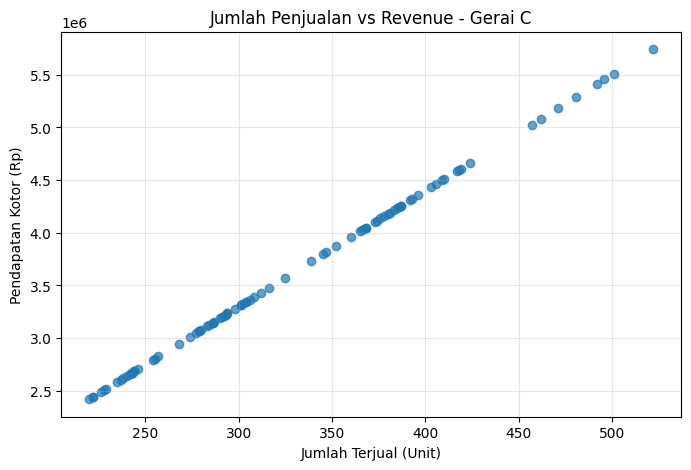

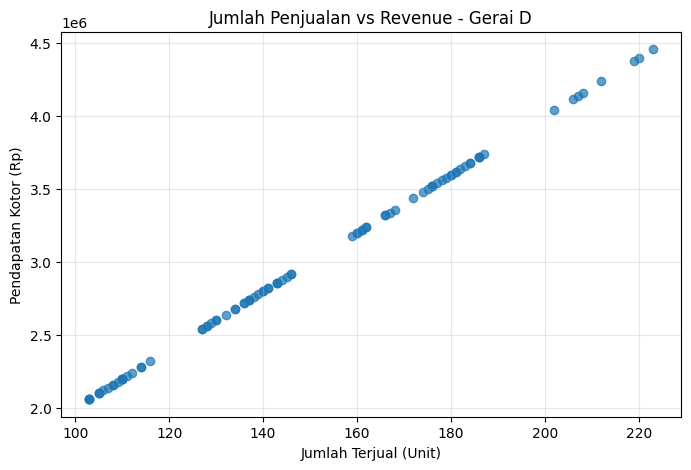

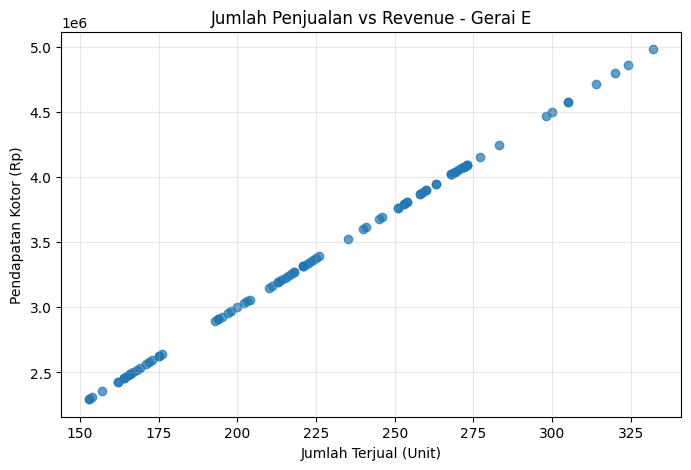

In [5]:
gerai_list = ['Gerai A', 'Gerai B', 'Gerai C', 'Gerai D', 'Gerai E']

for gerai in gerai_list:
    data = df[df['Gerai'] == gerai]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        data['Jumlah Terjual (Unit)'],
        data['Pendapatan Kotor (Rp)'],
        alpha=0.7
    )

    plt.title(f'Jumlah Penjualan vs Revenue - {gerai}')
    plt.xlabel('Jumlah Terjual (Unit)')
    plt.ylabel('Pendapatan Kotor (Rp)')
    plt.grid(alpha=0.3)

    plt.show()

### Interpretasi

Berdasarkan scatter plot pada kelima gerai, terlihat adanya hubungan
positif antara jumlah donat yang terjual dengan pendapatan kotor.
Semakin besar jumlah unit yang terjual, semakin besar pula pendapatan
yang diperoleh.

Pola titik data pada masing-masing gerai juga menunjukkan kecenderungan
linear. Oleh karena itu, regresi linear digunakan untuk memodelkan
hubungan antara jumlah penjualan dan pendapatan kotor.

In [6]:
hasil_regresi = []

for gerai in gerai_list:

    data = df[df['Gerai'] == gerai]

    X = data[['Jumlah Terjual (Unit)']]
    y = data['Pendapatan Kotor (Rp)']

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)

    hasil_regresi.append({
        'Gerai': gerai,
        'Koefisien (a)': a,
        'Intercept (b)': b,
        'R²': r2
    })

hasil_regresi_df = pd.DataFrame(hasil_regresi)

hasil_regresi_df

,Gerai,Koefisien (a),Intercept (b),R²
0,Gerai A,25000.0,-4.656613e-10,1.0
1,Gerai B,8000.0,0.000000e+00,1.0
2,Gerai C,11000.0,4.656613e-10,1.0
3,Gerai D,20000.0,-9.313226e-10,1.0
4,Gerai E,15000.0,-4.656613e-10,1.0


In [7]:
for _, row in hasil_regresi_df.iterrows():

    a = row['Koefisien (a)']
    b = row['Intercept (b)']

    print(f"{row['Gerai']}:")
    print(f"Revenue = {a:,.2f}x + {b:,.2f}")
    print(f"R² = {row['R²']:.4f}")
    print()

Gerai A:
Revenue = 25,000.00x + -0.00
R² = 1.0000

Gerai B:
Revenue = 8,000.00x + 0.00
R² = 1.0000

Gerai C:
Revenue = 11,000.00x + 0.00
R² = 1.0000

Gerai D:
Revenue = 20,000.00x + -0.00
R² = 1.0000

Gerai E:
Revenue = 15,000.00x + -0.00
R² = 1.0000



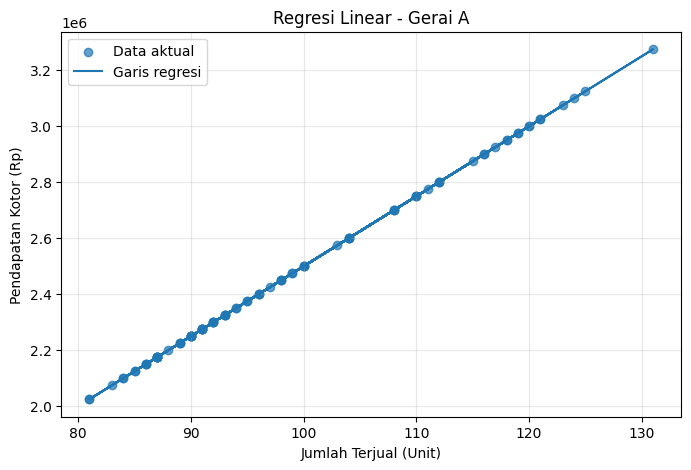

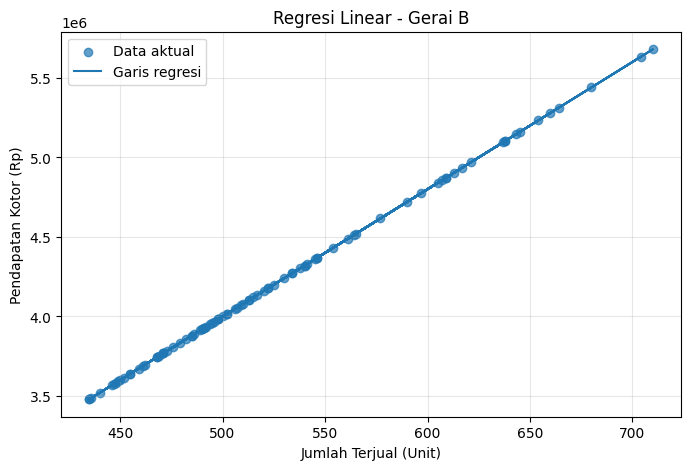

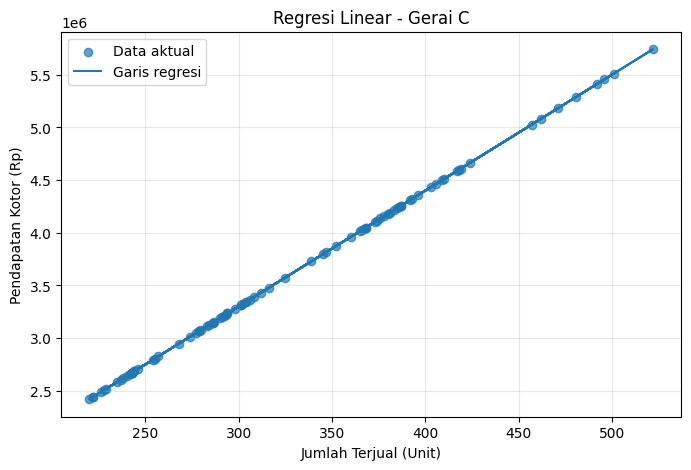

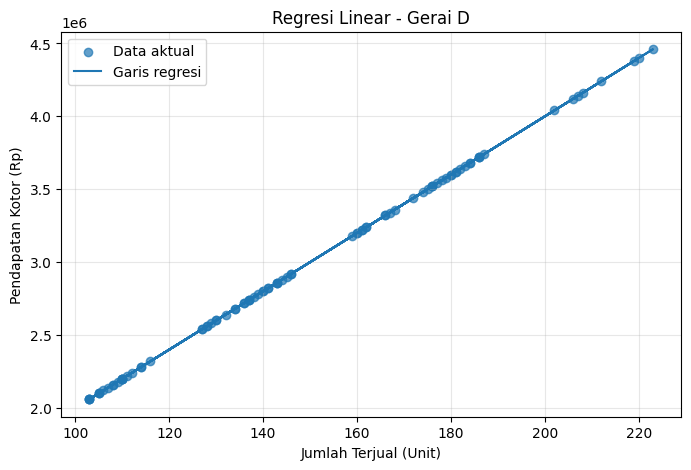

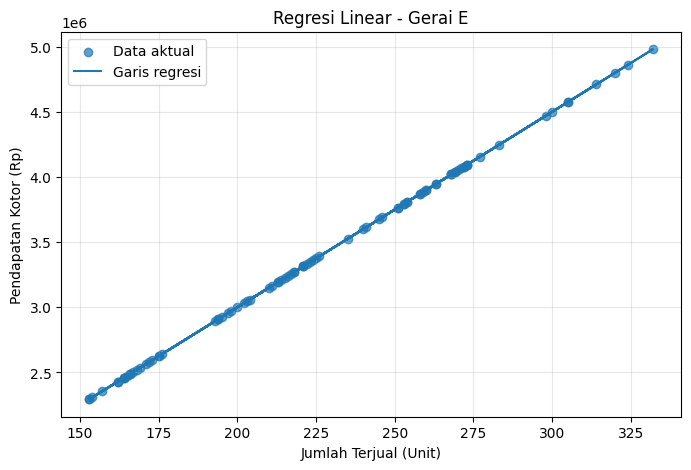

In [8]:
for gerai in gerai_list:

    data = df[df['Gerai'] == gerai]

    X = data[['Jumlah Terjual (Unit)']]
    y = data['Pendapatan Kotor (Rp)']

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    plt.figure(figsize=(8, 5))

    plt.scatter(
        data['Jumlah Terjual (Unit)'],
        y,
        alpha=0.7,
        label='Data aktual'
    )

    plt.plot(
        data['Jumlah Terjual (Unit)'],
        y_pred,
        label='Garis regresi'
    )

    plt.title(f'Regresi Linear - {gerai}')
    plt.xlabel('Jumlah Terjual (Unit)')
    plt.ylabel('Pendapatan Kotor (Rp)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

### Interpretasi Regresi

Hasil regresi menunjukkan bahwa hubungan antara jumlah penjualan
dan pendapatan kotor pada kelima gerai dapat dimodelkan menggunakan
regresi linear.

Nilai R² sebesar 1,0000 pada masing-masing gerai menunjukkan bahwa
model linear menjelaskan seluruh variasi pendapatan kotor berdasarkan
jumlah unit yang terjual pada dataset ini.

Koefisien regresi juga sesuai dengan harga jual masing-masing gerai.
Hal ini terjadi karena pendapatan kotor dihitung berdasarkan perkalian
antara harga jual per unit dan jumlah unit yang terjual.

In [9]:
ringkasan_biaya = []

for gerai in gerai_list:

    data = df[df['Gerai'] == gerai]

    variable_cost_per_unit = (
        data['Biaya Variabel (Rp)'] /
        data['Jumlah Terjual (Unit)']
    ).mean()

    fixed_cost = data['Fixed Cost Harian (Rp)'].iloc[0]

    harga = data['Harga Jual (Rp)'].iloc[0]

    ringkasan_biaya.append({
        'Gerai': gerai,
        'Harga Jual per Unit': harga,
        'Biaya Variabel per Unit': variable_cost_per_unit,
        'Fixed Cost Harian': fixed_cost
    })

biaya_df = pd.DataFrame(ringkasan_biaya)

biaya_df

,Gerai,Harga Jual per Unit,Biaya Variabel per Unit,Fixed Cost Harian
0,Gerai A,25000,8500.0,1683333
1,Gerai B,8000,4160.0,733333
2,Gerai C,11000,4840.0,1733333
3,Gerai D,20000,7200.0,2666666
4,Gerai E,15000,6300.0,800000


In [10]:
def bisection(f, a, b, tol=1e-6, max_iter=100):

    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError(
            "Interval tidak mengandung akar. "
            "Pilih interval yang berbeda."
        )

    for i in range(max_iter):

        c = (a + b) / 2
        fc = f(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, i + 1

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, max_iter

In [11]:
hasil_bep = []

for gerai in gerai_list:

    data = df[df['Gerai'] == gerai]

    # Regresi revenue
    X = data[['Jumlah Terjual (Unit)']]
    y = data['Pendapatan Kotor (Rp)']

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    # Biaya
    variable_cost_per_unit = (
        data['Biaya Variabel (Rp)'] /
        data['Jumlah Terjual (Unit)']
    ).mean()

    fixed_cost = data['Fixed Cost Harian (Rp)'].iloc[0]

    # Fungsi profit
    def fungsi_profit(x, a=a, b=b,
                      variable_cost_per_unit=variable_cost_per_unit,
                      fixed_cost=fixed_cost):

        return (
            a * x
            + b
            - variable_cost_per_unit * x
            - fixed_cost
        )

    # Batas pencarian
    batas_bawah = 0
    batas_atas = max(
        data['Jumlah Terjual (Unit)'].max() * 2,
        100
    )

    # Pastikan batas atas menghasilkan profit positif
    while fungsi_profit(batas_atas) < 0:
        batas_atas *= 2

    # Bisection
    akar, iterasi = bisection(
        fungsi_profit,
        batas_bawah,
        batas_atas
    )

    # Pembulatan ke atas
    bep_operasional = np.ceil(akar)

    hasil_bep.append({
        'Gerai': gerai,
        'Koefisien Revenue': a,
        'Biaya Variabel/Unit': variable_cost_per_unit,
        'Fixed Cost': fixed_cost,
        'BEP Matematis': akar,
        'Iterasi Bisection': iterasi,
        'BEP Operasional (Unit)': bep_operasional
    })

hasil_bep_df = pd.DataFrame(hasil_bep)

hasil_bep_df

,Gerai,Koefisien Revenue,Biaya Variabel/Unit,Fixed Cost,BEP Matematis,Iterasi Bisection,BEP Operasional (Unit)
0,Gerai A,25000.0,8500.0,1683333,102.020183,28,103.0
1,Gerai B,8000.0,4160.0,733333,190.972135,31,191.0
2,Gerai C,11000.0,4840.0,1733333,281.385228,30,282.0
3,Gerai D,20000.0,7200.0,2666666,208.333281,29,209.0
4,Gerai E,15000.0,6300.0,800000,91.954023,30,92.0


In [12]:
hasil_bep_df[
    [
        'Gerai',
        'BEP Matematis',
        'Iterasi Bisection',
        'BEP Operasional (Unit)'
    ]
]

,Gerai,BEP Matematis,Iterasi Bisection,BEP Operasional (Unit)
0,Gerai A,102.020183,28,103.0
1,Gerai B,190.972135,31,191.0
2,Gerai C,281.385228,30,282.0
3,Gerai D,208.333281,29,209.0
4,Gerai E,91.954023,30,92.0


In [14]:
validasi = []

for _, row in hasil_bep_df.iterrows():

    gerai = row['Gerai']
    bep = int(row['BEP Operasional (Unit)'])

    data = df[df['Gerai'] == gerai]

    harga = data['Harga Jual (Rp)'].iloc[0]

    variable_cost_per_unit = (
        data['Biaya Variabel (Rp)'] /
        data['Jumlah Terjual (Unit)']
    ).mean()

    fixed_cost = data['Fixed Cost Harian (Rp)'].iloc[0]

    profit_sebelum = (
        harga * (bep - 1)
        - variable_cost_per_unit * (bep - 1)
        - fixed_cost
    )

    profit_sesudah = (
        harga * bep
        - variable_cost_per_unit * bep
        - fixed_cost
    )

    validasi.append({
        'Gerai': gerai,
        'Unit Sebelum BEP': bep - 1,
        'Profit Sebelum BEP': profit_sebelum,
        'Unit BEP': bep,
        'Profit pada BEP Operasional': profit_sesudah
    })

validasi_df = pd.DataFrame(validasi)

validasi_df

,Gerai,Unit Sebelum BEP,Profit Sebelum BEP,Unit BEP,Profit pada BEP Operasional
0,Gerai A,102,-333.0,103,16167.0
1,Gerai B,190,-3733.0,191,107.0
2,Gerai C,281,-2373.0,282,3787.0
3,Gerai D,208,-4266.0,209,8534.0
4,Gerai E,91,-8300.0,92,400.0


In [15]:
rata_penjualan = (
    df.groupby('Gerai')['Jumlah Terjual (Unit)']
    .mean()
    .reset_index()
    .rename(columns={
        'Jumlah Terjual (Unit)': 'Rata-rata Penjualan'
    })
)

perbandingan = rata_penjualan.merge(
    hasil_bep_df[
        ['Gerai', 'BEP Operasional (Unit)']
    ],
    on='Gerai'
)

perbandingan
perbandingan['Selisih dari BEP'] = (
    perbandingan['Rata-rata Penjualan']
    - perbandingan['BEP Operasional (Unit)']
)

perbandingan

,Gerai,Rata-rata Penjualan,BEP Operasional (Unit),Selisih dari BEP
0,Gerai A,99.100000,103.0,-3.900000
1,Gerai B,527.500000,191.0,336.500000
2,Gerai C,328.933333,282.0,46.933333
3,Gerai D,149.833333,209.0,-59.166667
4,Gerai E,226.644444,92.0,134.644444


# Kesimpulan

Berdasarkan hasil analisis terhadap data lima gerai donat selama
90 hari, diperoleh hubungan yang linear antara jumlah unit yang
terjual dan pendapatan kotor.

Regresi linear digunakan untuk memodelkan hubungan tersebut karena
pola data menunjukkan hubungan linear. Hasil regresi menghasilkan
nilai R² sebesar 1,0000 pada masing-masing gerai, sehingga model
linear sangat sesuai dengan pola data yang diberikan.

Selanjutnya, persamaan revenue dari hasil regresi digunakan untuk
membentuk fungsi profit dengan mempertimbangkan biaya variabel dan
fixed cost harian. Break Even Point ditentukan dengan mencari akar
dari fungsi profit menggunakan metode Bisection.

Hasil pencarian akar menunjukkan bahwa jumlah penjualan yang
diperlukan untuk mencapai BEP secara operasional adalah:

- Gerai A: 103 unit/hari
- Gerai B: 191 unit/hari
- Gerai C: 282 unit/hari
- Gerai D: 209 unit/hari
- Gerai E: 92 unit/hari

Nilai tersebut merupakan pembulatan ke atas dari akar numerik,
karena jumlah unit penjualan harus berupa bilangan bulat dan
pembulatan ke atas memastikan gerai telah mencapai atau melewati
titik impas.